DATASET INFORMATION
Total transaction rows: 123
Columns: ['tx_hash', 'from', 'to', 'value', 'block_number']
Transactions with missing 'to': 3
Transactions with valid 'to': 120

GRAPH STATISTICS
Total transaction rows: 123
Valid sender → receiver transactions: 120
Contract creation transactions: 3
Unique addresses: 177
Unique sender → receiver relationships: 117
Self-loops: 0

TOP ADDRESSES BY DEGREE
0x87a3effb... degree = 36
0xea30c4b8... degree = 8
0x8f6eb787... degree = 6
0x73b668d8... degree = 5
0x2bd57c3c... degree = 4
0x60e8f2b6... degree = 3
0x7b79995e... degree = 2
0x333c2bc9... degree = 2
0x66a844f8... degree = 2
0xa984de6b... degree = 2

Calculating graph layout...

Graph saved as: ethereum_transaction_graph.png


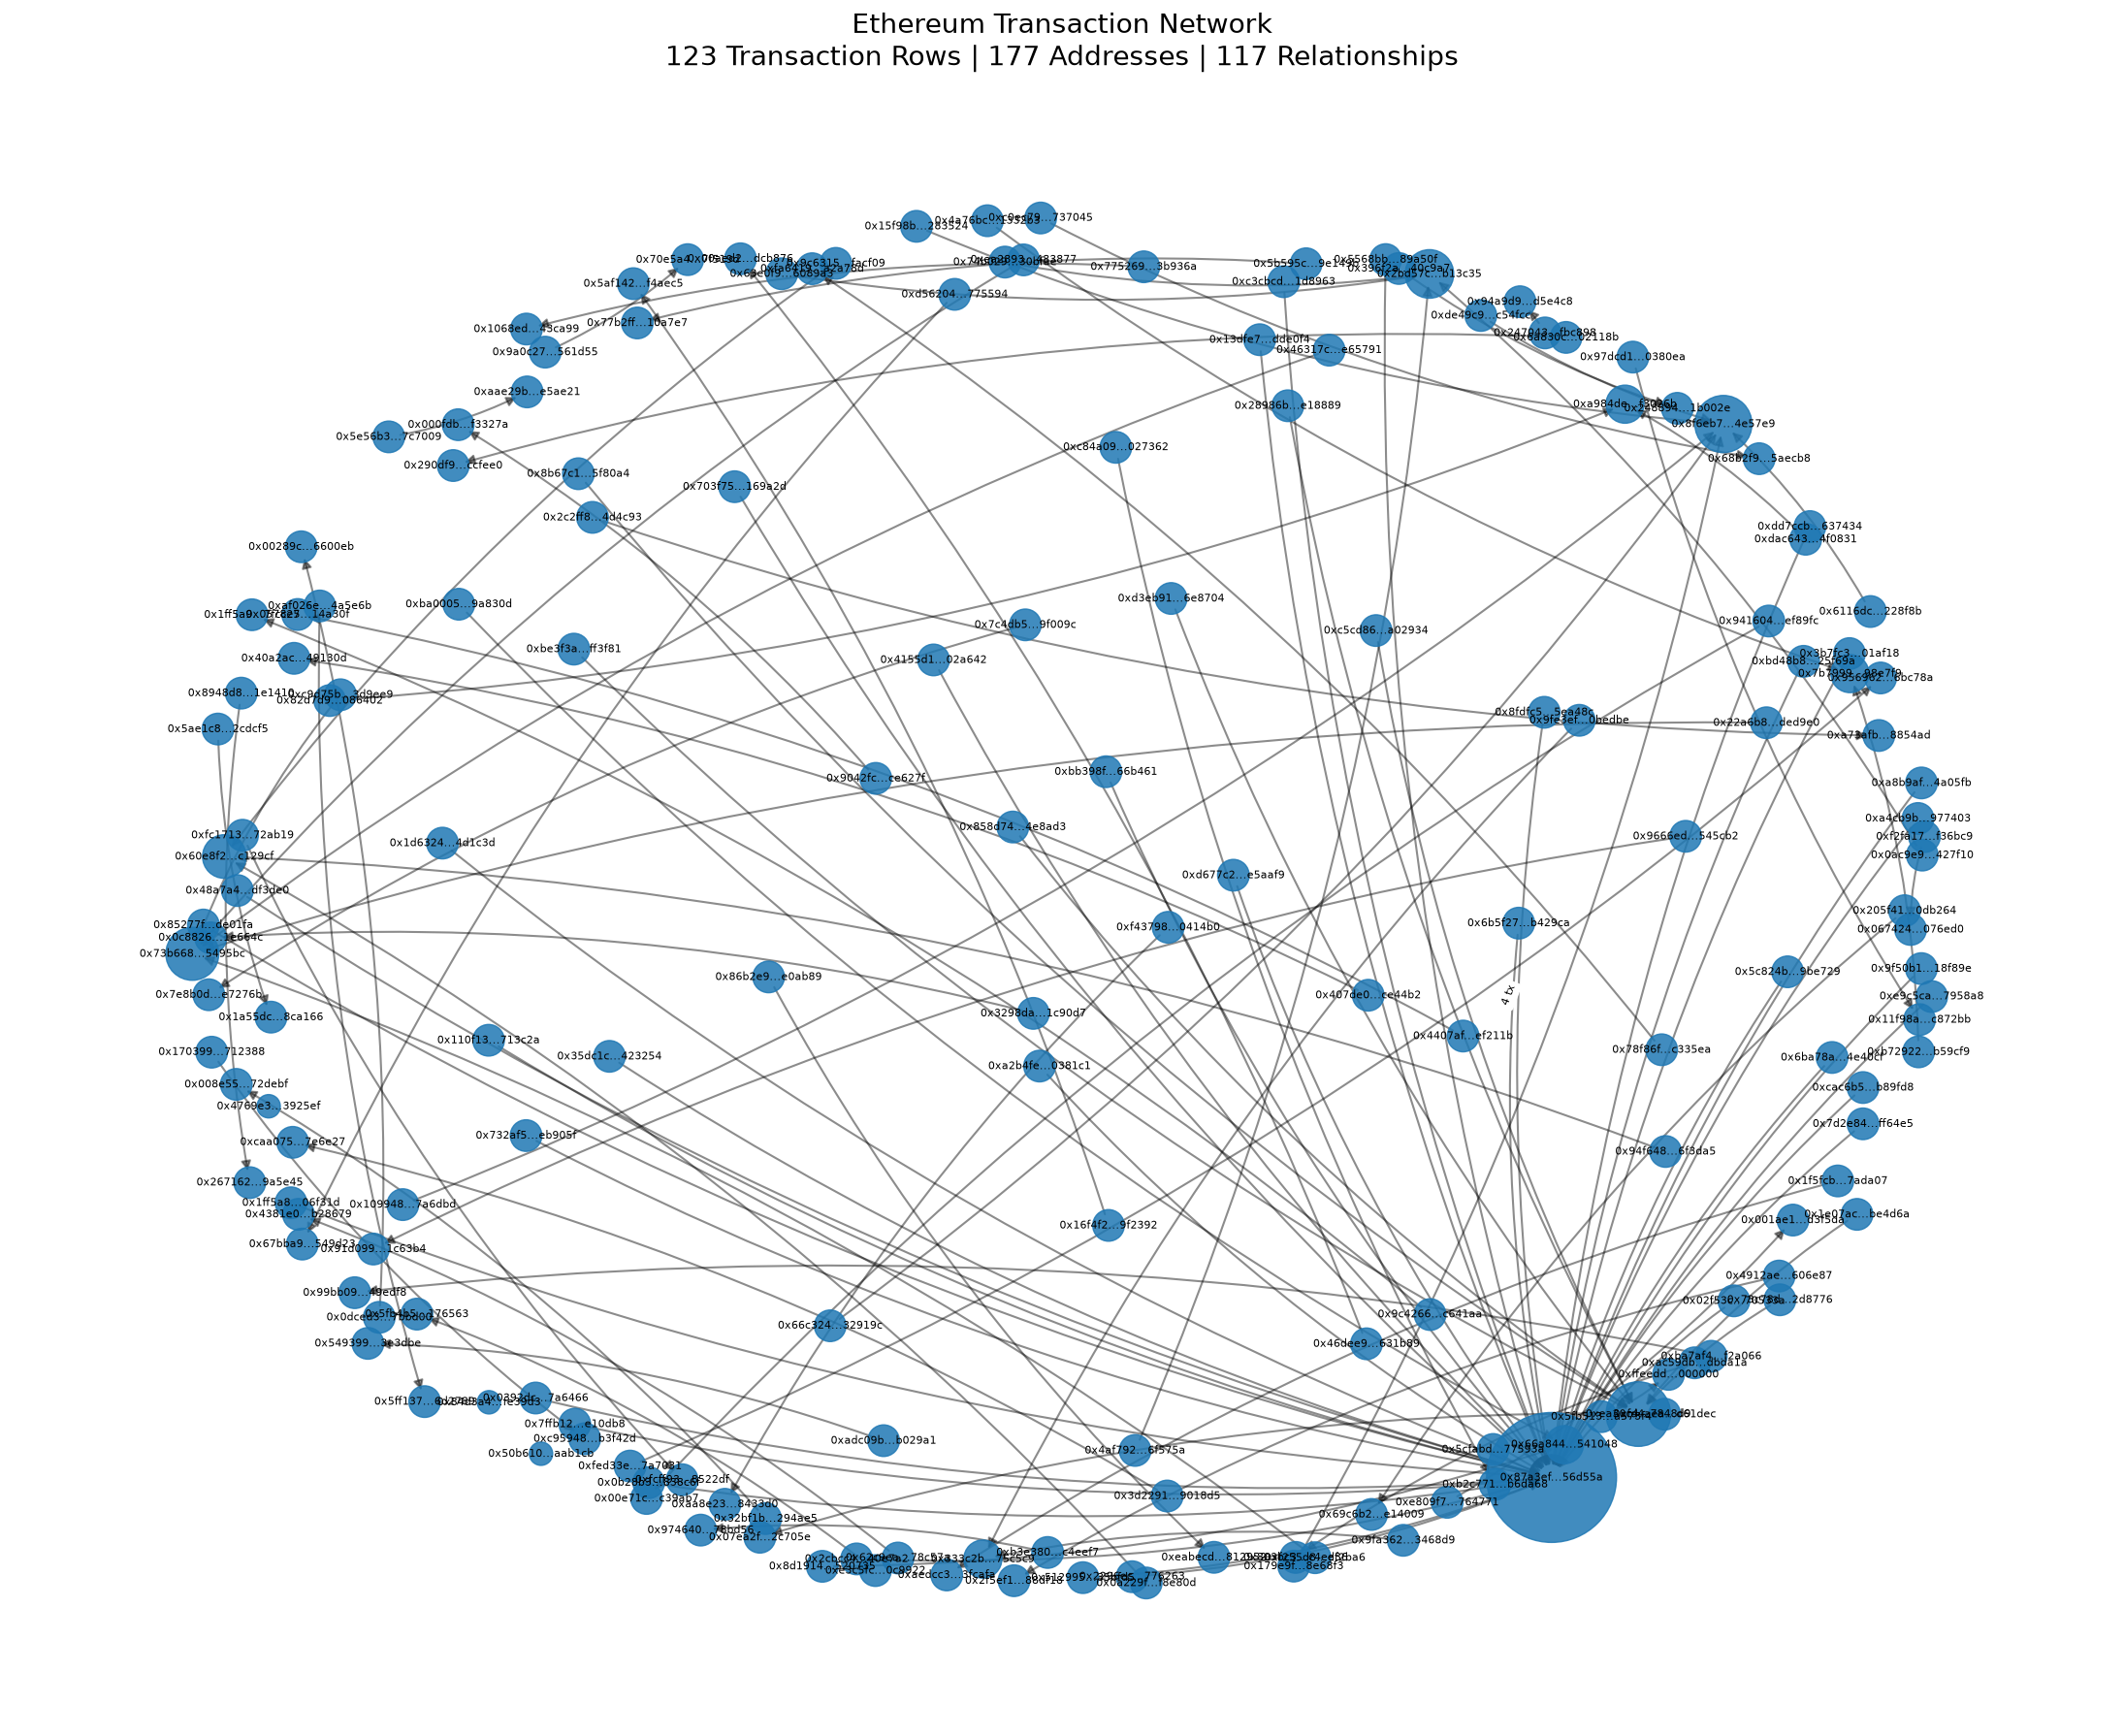

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. PUT YOUR CSV PATH HERE
# ============================================================

CSV_PATH = r"../../data/ehterblock.csv"


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(CSV_PATH)

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(f"Total transaction rows: {len(df)}")
print(f"Columns: {list(df.columns)}")


# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip().str.lower()

# Make sure required columns exist
required_columns = ["from", "to"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")


# ============================================================
# 4. CLEAN ADDRESSES
# ============================================================

df["from"] = df["from"].astype(str).str.strip()

# Convert empty / NaN-like values to real missing values
df["to"] = df["to"].replace(
    ["nan", "NaN", "None", "", "null", "NULL"],
    np.nan
)

df["to"] = df["to"].apply(
    lambda x: x.strip() if isinstance(x, str) else x
)


# ============================================================
# 5. BASIC DATA ANALYSIS
# ============================================================

missing_to = df["to"].isna().sum()

print(f"Transactions with missing 'to': {missing_to}")
print(f"Transactions with valid 'to': {len(df) - missing_to}")


# ============================================================
# 6. CREATE DIRECTED GRAPH
# ============================================================

G = nx.DiGraph()

valid_transactions = 0
contract_creation_transactions = 0

for index, row in df.iterrows():

    sender = row["from"]
    receiver = row["to"]

    # Ignore invalid sender
    if pd.isna(sender) or sender == "":
        continue

    # --------------------------------------------------------
    # Contract creation transaction
    # --------------------------------------------------------

    if pd.isna(receiver):

        contract_creation_transactions += 1

        # We DON'T create a node called NaN.
        #
        # Instead, keep the transaction information separately.

        G.add_node(
            sender,
            node_type="address"
        )

        continue

    # --------------------------------------------------------
    # Normal transaction
    # --------------------------------------------------------

    G.add_node(
        sender,
        node_type="address"
    )

    G.add_node(
        receiver,
        node_type="address"
    )

    # Transaction information
    tx_hash = row["tx_hash"] if "tx_hash" in df.columns else index

    # If multiple transactions exist between same addresses,
    # increase transaction count instead of losing the edge.

    if G.has_edge(sender, receiver):

        G[sender][receiver]["transaction_count"] += 1

        G[sender][receiver]["transactions"].append(tx_hash)

    else:

        G.add_edge(
            sender,
            receiver,
            transaction_count=1,
            transactions=[tx_hash]
        )

    valid_transactions += 1


# ============================================================
# 7. GRAPH STATISTICS
# ============================================================

print("\n" + "=" * 60)
print("GRAPH STATISTICS")
print("=" * 60)

print(f"Total transaction rows: {len(df)}")
print(f"Valid sender → receiver transactions: {valid_transactions}")
print(f"Contract creation transactions: {contract_creation_transactions}")
print(f"Unique addresses: {G.number_of_nodes()}")
print(f"Unique sender → receiver relationships: {G.number_of_edges()}")

print(f"Self-loops: {nx.number_of_selfloops(G)}")


# ============================================================
# 8. FIND HIGHLY CONNECTED ADDRESSES
# ============================================================

print("\n" + "=" * 60)
print("TOP ADDRESSES BY DEGREE")
print("=" * 60)

degree_list = sorted(
    G.degree(),
    key=lambda x: x[1],
    reverse=True
)

for address, degree in degree_list[:10]:

    print(
        f"{address[:10]}... "
        f"degree = {degree}"
    )


# ============================================================
# 9. GRAPH LAYOUT
# ============================================================

print("\nCalculating graph layout...")

plt.figure(figsize=(22, 18))

pos = nx.spring_layout(
    G,
    k=1.5,
    iterations=100,
    seed=42
)


# ============================================================
# 10. NODE SIZE BASED ON ACTIVITY
# ============================================================

node_sizes = []

for node in G.nodes():

    degree = G.degree(node)

    # Minimum size + activity-based size
    size = 300 + (degree * 250)

    node_sizes.append(size)


# ============================================================
# 11. DRAW NODES
# ============================================================

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.85
)


# ============================================================
# 12. DRAW EDGES
# ============================================================

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=15,
    arrowstyle="-|>",
    width=1.5,
    alpha=0.45,
    connectionstyle="arc3,rad=0.08"
)


# ============================================================
# 13. NODE LABELS
# ============================================================

labels = {}

for node in G.nodes():

    # Show only first 8 and last 6 characters
    if len(node) > 20:
        labels[node] = (
            node[:8] +
            "..." +
            node[-6:]
        )
    else:
        labels[node] = node


nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=8
)


# ============================================================
# 14. EDGE LABELS
# ============================================================

edge_labels = {}

for u, v, data in G.edges(data=True):

    count = data["transaction_count"]

    # Only show number if repeated
    if count > 1:
        edge_labels[(u, v)] = f"{count} tx"


nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)


# ============================================================
# 15. TITLE
# ============================================================

plt.title(
    f"Ethereum Transaction Network\n"
    f"{len(df)} Transaction Rows | "
    f"{G.number_of_nodes()} Addresses | "
    f"{G.number_of_edges()} Relationships",
    fontsize=20
)

plt.axis("off")

plt.tight_layout()


# ============================================================
# 16. SAVE GRAPH
# ============================================================

OUTPUT_PATH = "ethereum_transaction_graph.png"

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

print(f"\nGraph saved as: {OUTPUT_PATH}")

plt.show()